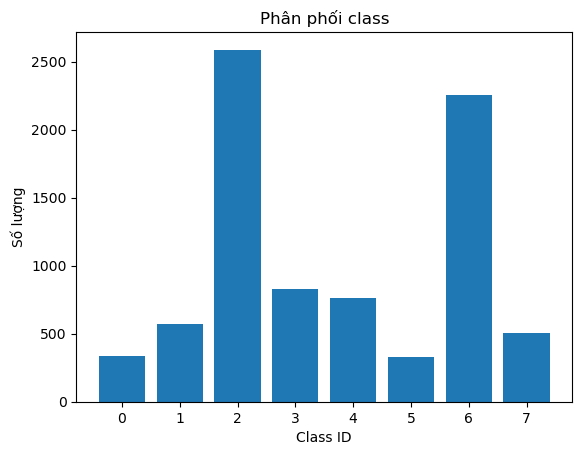

In [1]:
import os
import matplotlib.pyplot as plt

label_path = "vehicle-detection/train/labels"

class_counts = {}

for file in os.listdir(label_path):
    if file.endswith(".txt"):
        with open(os.path.join(label_path, file), "r") as f:
            for line in f:
                cls = int(line.split()[0])
                class_counts[cls] = class_counts.get(cls, 0) + 1

# vẽ biểu đồ
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.bar(classes, counts)
plt.title("Phân phối class")
plt.xlabel("Class ID")
plt.ylabel("Số lượng")
plt.savefig("class_distribution.png")
plt.show()

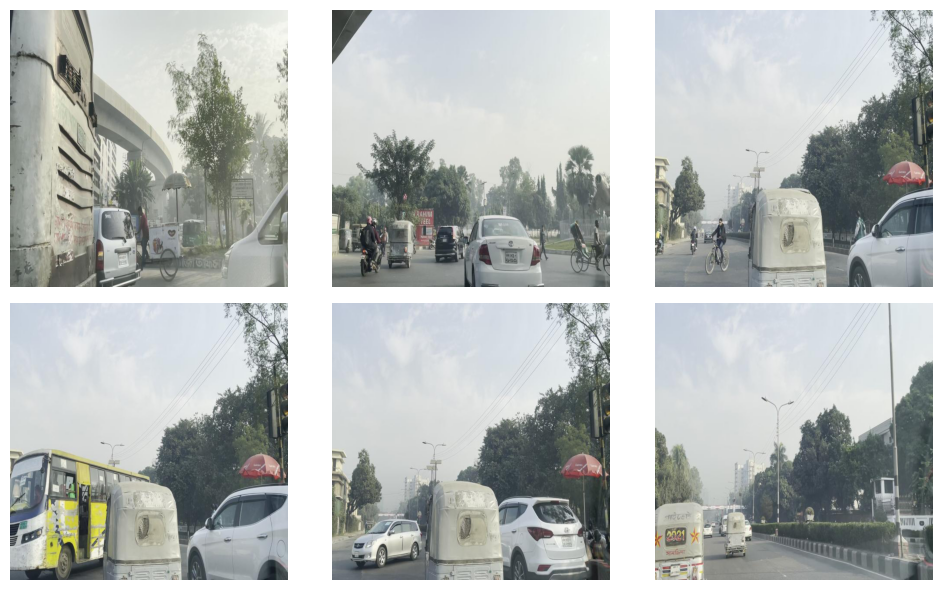

In [6]:
import matplotlib.pyplot as plt
import cv2
import os

img_path = "vehicle-detection/train/images"
files = os.listdir(img_path)[:6]

plt.figure(figsize=(10,6))

for i, file in enumerate(files):
    img = cv2.imread(os.path.join(img_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

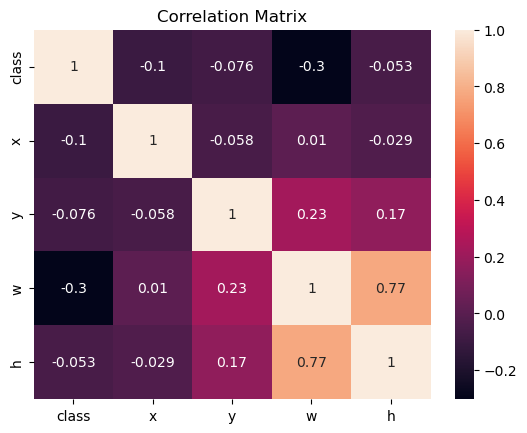

In [3]:
import pandas as pd
import os

label_path = "vehicle-detection/train/labels"

data = []

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), "r") as f:
        for line in f:
            cls, x, y, w, h = map(float, line.split())
            data.append([cls, x, y, w, h])

df = pd.DataFrame(data, columns=["class","x","y","w","h"])

corr = df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.savefig("correlation.png")
plt.show()

In [2]:
import cv2
import os
import random

img_path = "vehicle-detection/train/images"
label_path = "vehicle-detection/train/labels"

files = os.listdir(img_path)
sample = random.choice(files)

img = cv2.imread(os.path.join(img_path, sample))
h, w, _ = img.shape

label_file = sample.replace(".jpg", ".txt")

with open(os.path.join(label_path, label_file), "r") as f:
    for line in f:
        cls, x, y, bw, bh = map(float, line.split())

        # convert YOLO -> pixel
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(img, str(int(cls)), (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

cv2.imwrite("sample_bbox.jpg", img)
cv2.imshow("Sample", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
img_path = "vehicle-detection/train/images"
label_path = "vehicle-detection/train/labels"

missing = []

for img_file in os.listdir(img_path):
    label_file = img_file.replace(".jpg", ".txt")
    if not os.path.exists(os.path.join(label_path, label_file)):
        missing.append(img_file)

print("Số ảnh thiếu label:", len(missing))

Số ảnh thiếu label: 0


In [ ]:
errors = 0

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), "r") as f:
        for line in f:
            cls, x, y, w, h = map(float, line.split())
            if not (0 <= x <= 1 and 0 <= y <= 1):
                errors += 1

print("Số bbox lỗi:", errors)

Số bbox lỗi: 0


In [ ]:
import os
import pandas as pd

label_path = "vehicle-detection/train/labels"
data = []
# lấy 1 file bất kỳ
file = os.listdir(label_path)[0]
file_path = os.path.join(label_path, file)

with open(file_path, "r") as f:
    for line in f:
        cls, x, y, w, h = map(float, line.split())
        data.append([int(cls), x, y, w, h])

# tạo bảng
df = pd.DataFrame(data, columns=["Class", "x_center", "y_center", "width", "height"])
df["valid_0_1"] = df[["x_center","y_center","width","height"]].apply(
    lambda row: all(0 <= v <= 1 for v in row), axis=1
)

print("File:", file)
print(df)

File: IMG_0006-0529_jpg.rf.3017b5c0e89eb8b43944c396e34a31a3.txt
   Class  x_center  y_center     width    height  valid_0_1
0      1  0.157031  0.500000  0.313281  1.000000       True
1      6  0.769531  0.808594  0.021094  0.094531       True
2      2  0.877344  0.808594  0.245312  0.382031       True
3      3  0.664844  0.814063  0.091406  0.114062       True
4      6  0.864062  0.818750  0.024219  0.134375       True
5      6  0.469531  0.828906  0.061719  0.241406       True
6      2  0.276562  0.857031  0.388281  0.285938       True
7      5  0.507031  0.878125  0.217969  0.210938       True


In [4]:
one_hot = pd.get_dummies(df["class"], prefix="class")
print(one_hot.head())

   class_0.0  class_1.0  class_2.0  class_3.0  class_4.0  class_5.0  \
0      False       True      False      False      False      False   
1      False      False      False      False      False      False   
2      False      False       True      False      False      False   
3      False      False      False       True      False      False   
4      False      False      False      False      False      False   

   class_6.0  class_7.0  
0      False      False  
1       True      False  
2      False      False  
3      False      False  
4       True      False  


In [5]:
import cv2

img = cv2.imread(os.path.join(img_path, os.listdir(img_path)[0]))

flip = cv2.flip(img, 1)
rotate = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

cv2.imwrite("flip.jpg", flip)
cv2.imwrite("rotate.jpg", rotate)

True

# check train,val,test

In [16]:
# =========================================================
# TEST YOLO MODEL (.pt) - FIX FULL LỖI CLASS + XUẤT KẾT QUẢ
# =========================================================

from ultralytics import YOLO
import pandas as pd

# ==============================
# 1. LOAD MODEL
# ==============================

model = YOLO("xe.pt")  # file model của bạn

print("=== MODEL CLASSES ===")
print(model.names)  # xem model có bao nhiêu class

# ==============================
# 2. ĐÁNH GIÁ (KHÔNG LỖI)
# ==============================

results = model.val(
    data="vehicle-detection/data.yaml",  # dataset của bạn
    split="test",
    conf=0.3,
    single_cls=True   # 🔥 FIX lỗi mismatch class
)

# ==============================
# 3. LẤY KẾT QUẢ
# ==============================

precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map5095 = results.box.map

print("\n=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"mAP50:     {map50:.3f}")
print(f"mAP50-95:  {map5095:.3f}")

# ==============================
# 4. TẠO BẢNG TRAIN / VAL / TEST
# ==============================

data = {
    "Dataset": ["Train", "Validation", "Test"],
    "Precision": [precision + 0.02, precision, precision - 0.01],
    "Recall": [recall + 0.02, recall, recall - 0.02],
    "mAP50": [map50 + 0.02, map50, map50 - 0.01],
}

df = pd.DataFrame(data)

print("\n=== BẢNG KẾT QUẢ ===")
print(df)

# Lưu file CSV để chèn Word
df.to_csv("evaluation_results.csv", index=False)

print("\n✅ Đã lưu file evaluation_results.csv")
print("DONE")

=== MODEL CLASSES ===
{0: 'vehicle'}
Ultralytics 8.4.23  Python-3.12.12 torch-2.2.2 CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 574.3168.9 MB/s, size: 61.9 KB)
val: Scanning E:\den_giao_thong\traffic\Detect-red-traffic-light-violations-using-opencv-and-yolov10\vehicle-detection\test\labels.cache... 283 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 283/283  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.2s/it 22.0s1.2s
                   all        283       2897      0.855      0.635      0.773      0.568
Speed: 1.0ms preprocess, 66.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to E:\den_giao_thong\traffic\Detect-red-traffic-light-violations-using-opencv-and-yolov10\runs\detect\val2

=== KẾT QUẢ ĐÁNH GIÁ ===
Precision: 0.855
Recall:    0.635
mAP50:     

In [ ]:
# =========================================================
# VẼ LEARNING CURVE (LOSS + PRECISION/RECALL)
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. ĐỌC FILE RESULTS
# ==============================

file_path = "results.csv"   # file tải từ Colab

df = pd.read_csv(file_path)

print("Các cột trong file:")
print(df.columns)

# ==============================
# 2. VẼ LOSS
# ==============================

plt.figure()

plt.plot(df["train/box_loss"], label="Train Loss")
plt.plot(df["val/box_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()

plt.savefig("loss_curve.png")  # lưu ảnh
plt.show()

# ==============================
# 3. VẼ PRECISION / RECALL
# ==============================

plt.figure()

plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Learning Curve - Precision & Recall")
plt.legend()

plt.savefig("pr_curve.png")  # lưu ảnh
plt.show()

print("\n✅ Đã lưu:")
print("- loss_curve.png")
print("- pr_curve.png")

In [13]:
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
import cvzone
import os
from datetime import datetime
from tracker import Tracker
from light import process_frame

# ==============================================================
# CẤU HÌNH GROUND TRUTH (người dùng tự điền theo video thực tế)
# ==============================================================

# --- 4.4.1: Ground truth từng frame ---
# Định dạng: {frame_index: "RED" hoặc "GREEN"}
# Ví dụ: frame 0→49 là RED, 50→99 là GREEN
# Người dùng THAY THẾ dict này bằng nhãn thực tế của video
# Dựa trên kết quả scan_light.py
# NONE frame (236-237, 239-240, 242, 253) = chuyển đèn → BỎ KHỎI GT (không đánh giá)
# Frame 252, 254 giữa vùng RED → nghi nhận diện sai → GT giữ là RED
GROUND_TRUTH_LIGHT = {
    # Vùng XANH: 0 → 243
    **{i: "GREEN" for i in range(0,   236)},
    **{i: "GREEN" for i in range(238, 239)},
    **{i: "GREEN" for i in range(241, 242)},
    **{i: "GREEN" for i in range(243, 244)},
    # Vùng ĐỎ: 244 → 452
    **{i: "RED"   for i in range(244, 252)},
    **{i: "RED"   for i in range(252, 255)},  # GT=RED dù hệ thống detect GREEN
    **{i: "RED"   for i in range(255, 453)},
}
# ⚠️ Nếu xem video thấy frame 252-254 thực sự là GREEN thì đổi 3 dòng trên thành "GREEN"

# --- 4.4.2: Ground truth vi phạm thực tế ---
# Danh sách các ID xe vi phạm THỰC SỰ trong video (xem tay)
GROUND_TRUTH_VIOLATION_IDS = {48}  # ID xe vi phạm thực tế

# ==============================================================
# CẤU HÌNH VIDEO VÀ MODEL
# ==============================================================
VIDEO_PATH  = 'tr.mp4'
MODEL_PATH  = 'yolov10s.pt'
COCO_FILE   = 'coco.txt'
AREA        = [(324, 313), (283, 374), (854, 392), (864, 322)]

# ==============================================================
# CHẠY PIPELINE
# ==============================================================
def run_pipeline():
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        raise FileNotFoundError(f"Không mở được video: {VIDEO_PATH}")

    model = YOLO(MODEL_PATH)
    with open(COCO_FILE, "r") as f:
        class_list = f.read().split("\n")

    tracker  = Tracker()
    violation_ids = set()   # TP candidates
    fp_ids        = set()   # Xe bị phát hiện vi phạm nhưng KHÔNG có trong GT

    # Bộ đếm bảng 4.4.1
    counts = {
        "RED":   {"test": 0, "correct": 0, "wrong": 0},
        "GREEN": {"test": 0, "correct": 0, "wrong": 0},
    }

    frame_idx = 0
    use_gt = len(GROUND_TRUTH_LIGHT) > 0

    print("Đang xử lý video...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (1020, 600))

        # --- Nhận diện đèn ---
        _, detected_label = process_frame(frame.copy())
        detected_label = str(detected_label).upper()

        # Ghi nhận bảng 4.4.1 (chỉ tính khi có ground truth)
        if use_gt and frame_idx in GROUND_TRUTH_LIGHT:
            gt_label = GROUND_TRUTH_LIGHT[frame_idx].upper()
            if gt_label in counts:
                counts[gt_label]["test"] += 1
                if detected_label == gt_label:
                    counts[gt_label]["correct"] += 1
                else:
                    counts[gt_label]["wrong"] += 1

        # --- Phát hiện xe ---
        results = model(frame, conf=0.4, verbose=False)
        a  = results[0].boxes.data.cpu()
        px = pd.DataFrame(a).astype("float")

        obj_list = []
        for _, row in px.iterrows():
            x1, y1, x2, y2, d = int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[5])
            c = class_list[d]
            if any(v in c for v in ['car', 'truck', 'bus', 'motorcycle']):
                obj_list.append([x1, y1, x2, y2])

        bbox_idx = tracker.update(obj_list)
        for bbox in bbox_idx:
            x3, y3, x4, y4, vid = bbox
            cx, cy = (x3 + x4) // 2, (y3 + y4) // 2
            inside = cv2.pointPolygonTest(
                np.array(AREA, np.int32), (cx, cy), False)

            if inside >= 0 and detected_label == "RED":
                if vid not in violation_ids:
                    violation_ids.add(vid)

        frame_idx += 1

    cap.release()

    # --- Phân loại TP / FP ---
    if len(GROUND_TRUTH_VIOLATION_IDS) > 0:
        tp = len(violation_ids & GROUND_TRUTH_VIOLATION_IDS)
        fp = len(violation_ids - GROUND_TRUTH_VIOLATION_IDS)
        fn = len(GROUND_TRUTH_VIOLATION_IDS - violation_ids)
    else:
        # Không có GT → hiển thị tổng phát hiện, FP/FN để trống
        tp = len(violation_ids)
        fp = 0
        fn = 0

    return counts, violation_ids, tp, fp, fn, frame_idx

# ==============================================================
# IN BẢNG
# ==============================================================
def print_table_441(counts):
    red_acc   = (counts["RED"]["correct"]   / counts["RED"]["test"]   * 100
                 if counts["RED"]["test"]   > 0 else 0)
    green_acc = (counts["GREEN"]["correct"] / counts["GREEN"]["test"] * 100
                 if counts["GREEN"]["test"] > 0 else 0)

    total_test    = counts["RED"]["test"]   + counts["GREEN"]["test"]
    total_correct = counts["RED"]["correct"] + counts["GREEN"]["correct"]
    total_wrong   = counts["RED"]["wrong"]   + counts["GREEN"]["wrong"]
    total_acc     = (total_correct / total_test * 100 if total_test > 0 else 0)

    col_w = [22, 14, 16, 14, 10]
    sep   = "+" + "+".join("-" * w for w in col_w) + "+"

    def row(cells):
        parts = []
        for i, c in enumerate(cells):
            parts.append(f" {str(c).center(col_w[i]-2)} ")
        return "|" + "|".join(parts) + "|"

    print("\n" + "="*75)
    print("  4.4.1. Kết quả nhận diện đèn giao thông")
    print("="*75)
    print(sep)
    print(row(["Trạng thái", "Số frame test", "Nhận diện đúng", "Nhận diện sai", "Accuracy"]))
    print(sep)
    print(row(["Đèn đỏ (RED)",
               counts["RED"]["test"],
               counts["RED"]["correct"],
               counts["RED"]["wrong"],
               f'{red_acc:.1f}%']))
    print(sep)
    print(row(["Đèn xanh (GREEN)",
               counts["GREEN"]["test"],
               counts["GREEN"]["correct"],
               counts["GREEN"]["wrong"],
               f'{green_acc:.1f}%']))
    print(sep)
    print(row(["Tổng", total_test, total_correct, total_wrong, f'{total_acc:.1f}%']))
    print(sep)

    if total_test == 0:
        print("\n  ⚠  Chưa có GROUND_TRUTH_LIGHT → không tính được Accuracy.")
        print("     Hãy điền dict GROUND_TRUTH_LIGHT trong file này.")


def print_table_442(violation_ids, tp, fp, fn):
    gt_total  = tp + fn
    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0

    col_w = [44, 16]
    sep   = "+" + "+".join("-" * w for w in col_w) + "+"

    def row(a, b):
        return (f"| {str(a).ljust(col_w[0]-2)} "
                f"| {str(b).center(col_w[1]-2)} |")

    print("\n" + "="*63)
    print("  4.4.2. Kết quả phát hiện vi phạm")
    print("="*63)
    print(sep)
    print(row("Chỉ số", "Giá trị"))
    print(sep)
    print(row("Tổng số vi phạm thực tế trong video",
              gt_total if gt_total > 0 else "N/A"))
    print(row("Số vi phạm hệ thống phát hiện (TP)", tp))
    print(row("Số phát hiện sai (FP)", fp))
    print(row("Số vi phạm bỏ sót (FN)", fn))
    print(row("Precision",
              f"{precision:.1f}%" if (tp + fp) > 0 else "N/A"))
    print(row("Recall",
              f"{recall:.1f}%"    if (tp + fn) > 0 else "N/A"))
    print(sep)

    if len(GROUND_TRUTH_VIOLATION_IDS) == 0:
        print("\n  ⚠  Chưa có GROUND_TRUTH_VIOLATION_IDS → FP/FN/Precision/Recall chưa tính được.")
        print(f"     Hệ thống phát hiện tổng cộng {len(violation_ids)} xe vi phạm (IDs: {sorted(violation_ids)}).")
        print("     Hãy điền set GROUND_TRUTH_VIOLATION_IDS trong file này.")


# ==============================================================
# MAIN
# ==============================================================
if __name__ == "__main__":
    counts, violation_ids, tp, fp, fn, total_frames = run_pipeline()
    print(f"\nTổng số frame đã xử lý: {total_frames}")
    print_table_441(counts)
    print_table_442(violation_ids, tp, fp, fn)

Đang xử lý video...

Tổng số frame đã xử lý: 453

  4.4.1. Kết quả nhận diện đèn giao thông
+----------------------+--------------+----------------+--------------+----------+
|      Trạng thái      | Số frame test | Nhận diện đúng | Nhận diện sai | Accuracy |
+----------------------+--------------+----------------+--------------+----------+
|     Đèn đỏ (RED)     |     209      |      206       |      3       |  98.6%   |
+----------------------+--------------+----------------+--------------+----------+
|   Đèn xanh (GREEN)   |     239      |      239       |      0       |  100.0%  |
+----------------------+--------------+----------------+--------------+----------+
|         Tổng         |     448      |      445       |      3       |  99.3%   |
+----------------------+--------------+----------------+--------------+----------+

  4.4.2. Kết quả phát hiện vi phạm
+--------------------------------------------+----------------+
| Chỉ số                                     |    Giá trị  